<a href="https://colab.research.google.com/github/Faisalmalik01/Parkinsons_Voice_ML/blob/main/Parkinsons_Voice_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Parkinson's Disease Classification from Voice Recordings

**In one paragraph:** we take 1,134 voice recordings (a `Healthy` folder and a `Parkinsons` folder), check and clean them, turn every recording into 34 numbers that describe how the voice sounds, split the data into train / validation / test, train three models, choose the best one, test it once, and wrap it in a small web app.

> **Educational demo only. This is not a medical diagnosis tool.**

## The 9-step pipeline

| # | Step | What we do here |
|---|---|---|
| 1 | Problem definition | Voice audio in, Parkinson's or healthy out |
| 2 | Data acquisition | Mount Google Drive, unzip, inspect the files |
| 3 | Data cleaning | Check corrupt files, sample rates, durations, silence, **duplicates** |
| 4 | Data preprocessing | Fixed sample rate, trim silence, normalise volume |
| 5 | Data splitting | 70 / 15 / 15, stratified, before anything learns from the data |
| 6 | Feature extraction | 34 features (MFCC, pitch, energy), then scaling |
| 7 | Model implementation | Logistic Regression, SVM, Random Forest, cross-validation |
| 8 | Model evaluation | Test set opened once: accuracy, recall, F1, ROC-AUC |
| 9 | Deployment | Save the model and build a Gradio app |

## Results at a glance

| Item | Result |
|---|---|
| Raw files | 1,134 `.wav` (8 kHz, mono), 0 corrupt |
| Data problem found | 567 exact duplicates (every file appeared twice) |
| Unique recordings | 567 (287 healthy, 280 Parkinson's) |
| Split | 396 train / 85 validation / 86 test |
| Features | 34 per recording |
| Chosen model | Random Forest (CV 0.912, validation 0.918) |
| **Test set** | **accuracy 0.942, ROC-AUC 0.991**, Parkinson's recall 0.90, precision 0.97 |
| Honest range | about 91 to 94% (the test set has only 86 files) |

## About the dataset (read this)

- Source: Kaggle, *Parkinson's Voice Dataset*. The data is **not included** in this notebook.
- **The dataset page gives no documentation** of where the recordings came from, who the participants were, or how they were recorded. When this notebook was written, a user's request for that information had no reply. So the labels are taken as given and are **unverified**, and the clips only *appear* to be sustained sounds.
- File names are just numbers (`healthy_262.wav`), so there are **no speaker IDs**.

## How to run

1. Download the zip from Kaggle and upload it to the root of your Google Drive as `archive.zip`.
2. In Colab: **Runtime, then Run all**. Features and the model are saved to `MyDrive/ml_project/`.
3. If Colab disconnects, run the cells again from the top (memory is wiped, Drive files are not).

---
# Step 1: Problem definition

Before touching any data we write down exactly what we are solving.

| | |
|---|---|
| **Task** | Binary classification: Parkinson's (1) vs healthy (0) |
| **Input** | One voice recording (`.wav` audio) |
| **Output** | The predicted class, plus a probability |
| **Success metric** | Recall on the Parkinson's class, plus F1 and accuracy |
| **Why recall** | Missing a real patient is worse than a false alarm |
| **Why it matters** | Parkinson's makes the voice less steady, and a voice recording is cheap, non-invasive and can be collected remotely |

**Supervised learning:** we show the model examples *with the correct answers* (labels), it finds a pattern, and then it predicts answers for new recordings.

---
# Step 2: Data acquisition

**Goal:** get the audio files into Colab and look at them.

**Setup cell:** imports every library once at the top (a *library* is a toolbox someone else already wrote), then connects Google Drive so files survive a Colab reset.

| Library | Used for |
|---|---|
| `pandas`, `numpy` | Tables and fast maths |
| `matplotlib`, `seaborn` | Charts |
| `soundfile`, `librosa` | Reading and analysing audio |
| `hashlib` | File fingerprints (to find duplicates) |
| `scikit-learn` (`sklearn`) | Splitting, scaling, models, metrics |
| `joblib` | Saving the trained model |

In [1]:
import os, glob, hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import soundfile as sf
import librosa
import joblib

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (accuracy_score, f1_score, recall_score, roc_auc_score,
                             confusion_matrix, classification_report,
                             ConfusionMatrixDisplay, RocCurveDisplay)

from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


**Unzip cell:** copies the zip's contents to Colab's local disk (much faster to read from than Drive). The `!` means "run this as a terminal command", `-q` means quiet.

In [2]:
!unzip -q "/content/drive/MyDrive/archive.zip" -d /content/data

**First look:** `os.walk` walks through the folders, and `glob` finds files by pattern (`*.wav` means "every file ending in .wav").

**What we found:** two folders, 574 healthy and 560 Parkinson's files, all `.wav`, named like `healthy_262.wav`. No speaker information in the names.

> A `.wav` file is a long list of numbers, one per tiny slice of time. The **sample rate** is how many numbers per second (ours: 8000), so a 3-second clip is 24,000 numbers.

In [3]:
root = '/content/data'
# find the two class folders wherever they ended up
for dirpath, dirnames, filenames in os.walk(root):
    if dirnames or filenames:
        print(dirpath, '| subfolders:', len(dirnames), '| files:', len(filenames))
    if dirpath.count(os.sep) > 6:
        break

# count files by type in each class
for cls in ['Healthy', 'Parkinsons']:
    files = glob.glob(f'{root}/**/{cls}/**/*.*', recursive=True)
    exts = {}
    for f in files:
        e = os.path.splitext(f)[1].lower()
        exts[e] = exts.get(e, 0) + 1
    print(f"\n{cls}: {len(files)} files, types: {exts}")
    print("Example names:", [os.path.basename(f) for f in files[:8]])

/content/data | subfolders: 1 | files: 0
/content/data/Voice_Dataset | subfolders: 2 | files: 0
/content/data/Voice_Dataset/Parkinsons | subfolders: 0 | files: 560
/content/data/Voice_Dataset/Healthy | subfolders: 0 | files: 574

Healthy: 574 files, types: {'.wav': 574}
Example names: ['healthy_262.wav', 'healthy_315.wav', 'healthy_509.wav', 'healthy_045.wav', 'healthy_002.wav', 'healthy_571.wav', 'healthy_380.wav', 'healthy_348.wav']

Parkinsons: 560 files, types: {'.wav': 560}
Example names: ['parkinsons_237.wav', 'parkinsons_364.wav', 'parkinsons_209.wav', 'parkinsons_510.wav', 'parkinsons_556.wav', 'parkinsons_462.wav', 'parkinsons_104.wav', 'parkinsons_178.wav']


---
# Step 3: Data cleaning

**Goal:** check that the data is usable and honest *before* modelling.

| Check | Why it matters |
|---|---|
| Corrupt files | A broken file would crash the pipeline later |
| Sample rate | Different rates make features not comparable |
| Duration | Very short clips carry little voice; a big duration gap between classes could be a shortcut |
| Silent files | A recording with no sound is useless |
| **Duplicates** | If the same file is in train *and* test, the test score is fake |

**The loop below** opens every file once and records its facts: sample rate, channels, duration, loudness (**RMS**, the average loudness) and an **MD5 fingerprint** (a 32-character code of the file's exact bytes: identical bytes always give an identical fingerprint). A `try/except` makes sure one broken file doesn't stop everything.

**What we found:** 0 corrupt files, all 8000 Hz mono, no silent files, and **567 exact duplicates**.

In [4]:
root = '/content/data/Voice_Dataset'
rows = []

for label, cls in [(0, 'Healthy'), (1, 'Parkinsons')]:
    for path in sorted(glob.glob(f'{root}/{cls}/*.wav')):
        try:
            audio, sr = sf.read(path)
            if audio.ndim > 1:                       # stereo -> mono just for checking
                channels = audio.shape[1]
                audio = audio.mean(axis=1)
            else:
                channels = 1
            rows.append({
                'path': path,
                'label': label,
                'sr': sr,
                'channels': channels,
                'duration_s': len(audio) / sr,
                'peak': np.abs(audio).max(),         # loudest point
                'rms': np.sqrt(np.mean(audio**2)),   # average loudness
                'md5': hashlib.md5(open(path, 'rb').read()).hexdigest(),
                'ok': True
            })
        except Exception as e:
            rows.append({'path': path, 'label': label, 'ok': False, 'error': str(e)})

meta = pd.DataFrame(rows)

print("Corrupt / unreadable files:", (~meta['ok']).sum())
good = meta[meta['ok']].copy()

print("\nSample rates:\n", good['sr'].value_counts())
print("\nChannels:\n", good['channels'].value_counts())
print("\nDuration (seconds) by class:")
print(good.groupby('label')['duration_s'].describe().round(2))
print("\nQuietest 5 files (rms):")
print(good.nsmallest(5, 'rms')[['path', 'rms', 'duration_s']])
print("\nExact duplicate files:", good['md5'].duplicated().sum())

Corrupt / unreadable files: 0

Sample rates:
 sr
8000    1134
Name: count, dtype: int64

Channels:
 channels
1    1134
Name: count, dtype: int64

Duration (seconds) by class:
       count  mean   std   min   25%   50%   75%   max
label                                                 
0      574.0  3.03  1.05  1.48  1.99  2.87  3.86  5.76
1      560.0  3.54  1.49  1.38  2.40  3.30  4.13  7.21

Quietest 5 files (rms):
                                                   path       rms  duration_s
823   /content/data/Voice_Dataset/Parkinsons/parkins...  0.077995      4.0915
1103  /content/data/Voice_Dataset/Parkinsons/parkins...  0.077995      4.0915
825   /content/data/Voice_Dataset/Parkinsons/parkins...  0.084874      3.7195
1105  /content/data/Voice_Dataset/Parkinsons/parkins...  0.084874      3.7195
263   /content/data/Voice_Dataset/Healthy/healthy_26...  0.086078      4.6505

Exact duplicate files: 567


**Who are the duplicates?** Group the files by fingerprint and count copies and labels.

**What we found:** every unique file has exactly **2 copies**, and no pair sits in *both* classes, so there are no contradictory labels. Removing duplicates is safe.

> If we had split randomly with duplicates in, one copy would land in train and its twin in test. The model would be "tested" on audio it had already seen and show a fake accuracy of around 99%.

In [5]:
# how many copies does each unique file have?
copies = good.groupby('md5').agg(
    n_copies=('path', 'count'),
    n_labels=('label', 'nunique'),       # 1 = same class, 2 = in BOTH classes
    label=('label', 'first')
)

print("Copies per unique file:\n", copies['n_copies'].value_counts())
print("\nFiles whose copies sit in BOTH classes:", (copies['n_labels'] > 1).sum())
print("\nUnique files per class:\n", copies['label'].value_counts())

# a few examples of duplicate pairs
dup_md5 = copies[copies['n_copies'] > 1].index[:3]
for m in dup_md5:
    print([os.path.basename(p) for p in good.loc[good['md5'] == m, 'path']])

Copies per unique file:
 n_copies
2    567
Name: count, dtype: int64

Files whose copies sit in BOTH classes: 0

Unique files per class:
 label
0    287
1    280
Name: count, dtype: int64
['parkinsons_171.wav', 'parkinsons_451.wav']
['healthy_282.wav', 'healthy_569.wav']
['healthy_163.wav', 'healthy_450.wav']


**Keep one copy of each file.** `drop_duplicates(subset='md5')` keeps the first file per fingerprint. 1,134 files become **567 unique recordings (287 healthy, 280 Parkinson's)**.

In [6]:
# keep the first copy of every unique file
clean = good.drop_duplicates(subset='md5', keep='first').reset_index(drop=True)

print("Before:", len(good), "| After:", len(clean))
print(clean['label'].value_counts())

Before: 1134 | After: 567
label
0    287
1    280
Name: count, dtype: int64


**Proof that they are plain copies, not augmentations.** Augmentation (noise, time-stretch) changes the samples, so fingerprints would differ. Here a pair has identical fingerprints *and* identical waveforms.

In [7]:
a, _ = librosa.load('/content/data/Voice_Dataset/Parkinsons/parkinsons_171.wav', sr=8000)
b, _ = librosa.load('/content/data/Voice_Dataset/Parkinsons/parkinsons_451.wav', sr=8000)
print("Identical waveforms:", np.array_equal(a, b))

Identical waveforms: True


---
# Step 4: Data preprocessing

**Goal:** make every recording comparable. Each file is processed on its own, so nothing leaks between files.

| Line | What it does | Why |
|---|---|---|
| `librosa.load(path, sr=8000, mono=True)` | Load at one sample rate and one channel | All recordings must share one format |
| `librosa.effects.trim(y, top_db=25)` | Cut silence at the start and end | Silent gaps hold no voice information |
| `y / peak` | Make the loudest point exactly 1.0 | Removes microphone-volume differences |

The same `preprocess` function is reused in the web app, so new audio is treated exactly like training audio.

In [8]:
SR = 8000

def preprocess(path):
    y, _ = librosa.load(path, sr=SR, mono=True)        # 1. load at fixed sample rate
    y, _ = librosa.effects.trim(y, top_db=25)           # 2. cut leading/trailing silence
    peak = np.abs(y).max()
    if peak > 0:
        y = y / peak                                    # 3. peak normalize to [-1, 1]
    return y

clean['audio'] = clean['path'].apply(preprocess)
clean['duration_after'] = clean['audio'].apply(lambda y: len(y) / SR)

print(clean.groupby('label')['duration_after'].describe().round(2))

       count  mean   std   min   25%   50%   75%   max
label                                                 
0      287.0  3.03  1.05  1.48  2.01  2.87  3.86  5.76
1      280.0  3.54  1.50  1.38  2.40  3.30  4.13  7.21


**Check with a picture** (one clip per class, raw vs after preprocessing).

**What we found:** the plots barely change and the duration table is the same as before. The dataset **arrived already trimmed and normalised**, so there was nothing to cut. We keep the step anyway because the deployed app will receive new, untreated audio. (Note: trimming only cuts the *edges*; silence in the *middle* of a clip is not removed.)

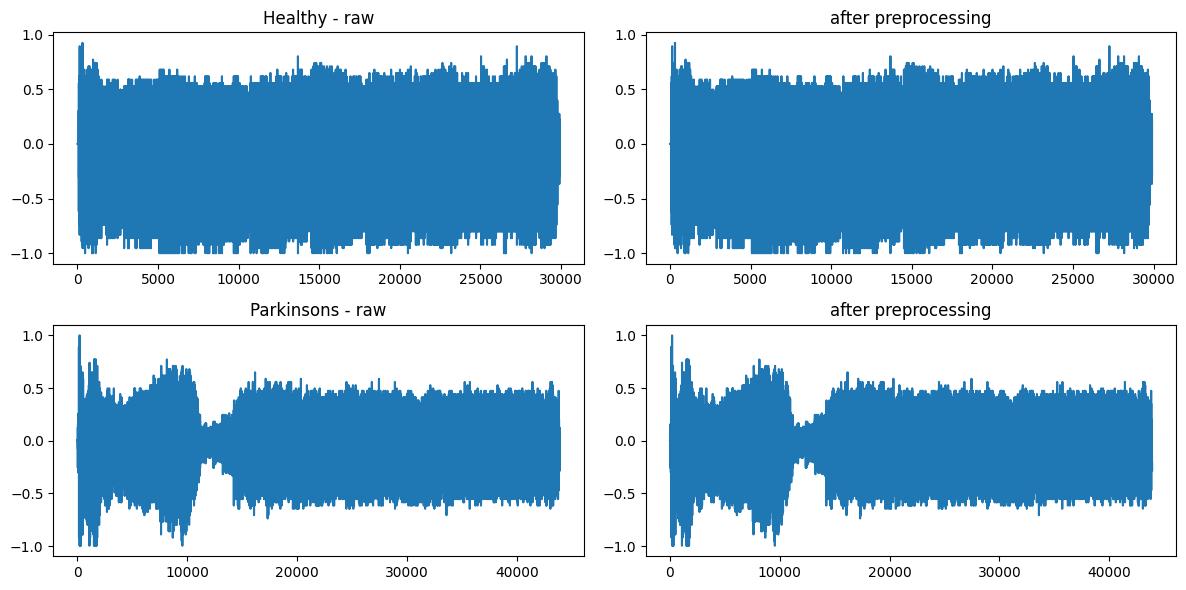

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12, 6))
for row, label in enumerate([0, 1]):
    p = clean[clean['label'] == label].iloc[0]
    raw, _ = librosa.load(p['path'], sr=SR)
    axes[row, 0].plot(raw);        axes[row, 0].set_title(f"{'Healthy' if label==0 else 'Parkinsons'} - raw")
    axes[row, 1].plot(p['audio']); axes[row, 1].set_title("after preprocessing")
plt.tight_layout(); plt.show()

---
# Step 5: Data splitting (70 / 15 / 15)

We split the **file list** before extracting any features. Each part has a different job:

| Set | Size | Job |
|---|---|---|
| **Train** | 396 (70%) | The model learns from these |
| **Validation** | 85 (15%) | We compare models on these |
| **Test** | 86 (15%) | Looked at **once**, at the very end, for the honest final score |

*Analogy:* train is the textbook, validation is the practice exam used to decide how to study, test is the final exam. If the student sees the final exam beforehand, the grade means nothing.

- `stratify=` keeps the healthy / Parkinson's ratio the same in every part.
- `random_state=42` fixes the shuffle so everyone gets the same split.
- The overlap check compares fingerprints and should print **0** for every pair.

**Limitation:** no speaker IDs, so recordings from the same person may sit on both sides of the split. A speaker-aware split would be better but this dataset doesn't allow it.

In [10]:
# 70% train, 30% temporary
train_df, temp_df = train_test_split(
    clean, test_size=0.30, stratify=clean['label'], random_state=42
)
# split the 30% in half -> 15% val, 15% test
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df['label'], random_state=42
)

for name, d in [('train', train_df), ('val', val_df), ('test', test_df)]:
    print(f"{name:5s} | {len(d):3d} files | healthy: {(d['label']==0).sum():3d} | parkinsons: {(d['label']==1).sum():3d}")

# safety check: no file appears in two splits
sets = [set(d['md5']) for d in (train_df, val_df, test_df)]
print("\nOverlap train/val:", len(sets[0] & sets[1]))
print("Overlap train/test:", len(sets[0] & sets[2]))
print("Overlap val/test:", len(sets[1] & sets[2]))

train | 396 files | healthy: 200 | parkinsons: 196
val   |  85 files | healthy:  43 | parkinsons:  42
test  |  86 files | healthy:  44 | parkinsons:  42

Overlap train/val: 0
Overlap train/test: 0
Overlap val/test: 0


**Shortcut check: can clip length alone predict the label?** The Parkinson's clips are longer on average (3.54 s vs 3.03 s). We train a model that sees *only* the duration. A score near 0.50 means length is not a hidden shortcut.

**What we found:** 0.494, which is coin-flip level. Not a shortcut.

In [11]:
shortcut = LogisticRegression()
shortcut.fit(train_df[['duration_after']], train_df['label'])
print("Accuracy using duration only (val):",
      round(shortcut.score(val_df[['duration_after']], val_df['label']), 3))

Accuracy using duration only (val): 0.494


---
# Step 6: Feature extraction

**The problem:** a model can't learn from a raw waveform. A 3-second clip is 24,000 numbers and most of them are just the wave wiggling. We need a short list of numbers that describes *how the voice sounds*.

**Frames:** we slide a small window along the audio (`n_fft=512` samples = 64 ms, moving `hop_length=128` samples = 16 ms each time), describe each window, then summarise across windows with a **mean** (typical value) and a **std** (how much it varies).

| Group | What it measures | Features |
|---|---|---|
| **MFCCs** (13) | The "shape" of the sound, from throat, tongue and mouth | mean + std = 26 |
| **Pitch** | How high the voice is and how much it wobbles | mean, std, voiced ratio = 3 |
| **Energy / spectral** | Loudness, noisiness, brightness | RMS mean/std, zero-crossing rate, spectral centroid mean/std = 5 |

Total: **34 features per recording**.

**MFCC in plain words:** for each 64 ms window, find how much energy there is at each frequency (a spectrum), squash the frequencies onto the **mel scale** (how human hearing spaces them), take the logarithm, and compress to 13 numbers. Together they are a compact fingerprint of the voice's shape.

**Picture first:** the MFCC grid of one healthy and one Parkinson's clip (13 rows by time; red is high, blue is low). One clip each, so don't over-read the difference.

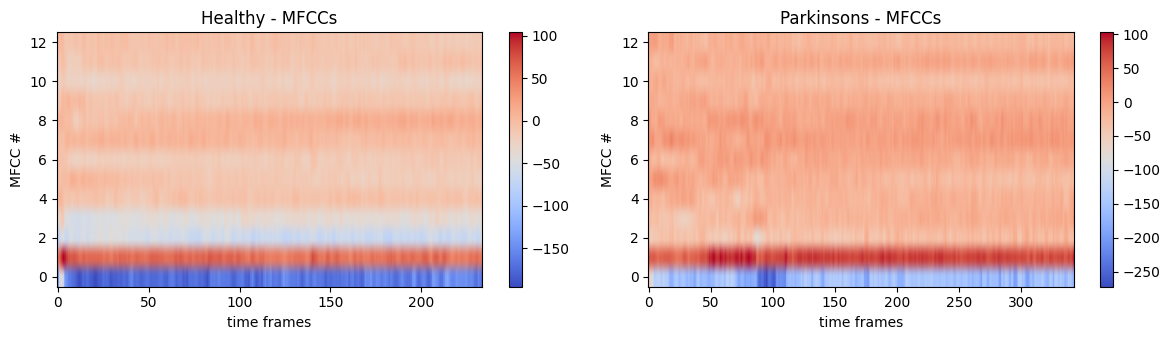

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
for ax, label, title in zip(axes, [0, 1], ['Healthy', 'Parkinsons']):
    y = clean[clean['label'] == label].iloc[0]['audio']
    m = librosa.feature.mfcc(y=y, sr=SR, n_mfcc=13, n_fft=512, hop_length=128)
    img = ax.imshow(m, aspect='auto', origin='lower', cmap='coolwarm')
    ax.set_title(f'{title} - MFCCs'); ax.set_xlabel('time frames'); ax.set_ylabel('MFCC #')
    plt.colorbar(img, ax=ax)
plt.tight_layout(); plt.show()

**Extraction cell:** `extract_features` turns one clip into a dictionary of 34 numbers, `build_table` does it for every clip in a split. `X` means inputs (features), `y` means answers (labels), a standard ML convention. The pitch tracker (`pyin`) searches 60 to 400 Hz, which covers normal speaking voices, and returns `NaN` for unvoiced moments, which we filter out.

**What we found:** shapes (396, 34), (85, 34), (86, 34) and **0 missing values**. This cell takes a few minutes.

In [13]:
def extract_features(y, sr=SR):
    f = {}
    # 1) MFCCs: 13 coefficients, summarised over time
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13, n_fft=512, hop_length=128)
    for i in range(13):
        f[f'mfcc{i+1}_mean'] = mfcc[i].mean()
        f[f'mfcc{i+1}_std']  = mfcc[i].std()

    # 2) Pitch (f0) using pyin; unvoiced frames come back as NaN
    f0, voiced, _ = librosa.pyin(y, fmin=60, fmax=400, sr=sr, frame_length=1024)
    f0v = f0[~np.isnan(f0)]
    f['pitch_mean']    = f0v.mean() if len(f0v) > 0 else 0
    f['pitch_std']     = f0v.std()  if len(f0v) > 0 else 0
    f['voiced_ratio']  = np.mean(voiced)

    # 3) Energy and spectral shape
    rms = librosa.feature.rms(y=y, frame_length=512, hop_length=128)[0]
    f['rms_mean'], f['rms_std'] = rms.mean(), rms.std()
    f['zcr_mean'] = librosa.feature.zero_crossing_rate(y, frame_length=512, hop_length=128)[0].mean()
    cent = librosa.feature.spectral_centroid(y=y, sr=sr, n_fft=512, hop_length=128)[0]
    f['centroid_mean'], f['centroid_std'] = cent.mean(), cent.std()
    return f

def build_table(d):
    X = pd.DataFrame([extract_features(a) for a in d['audio']])
    return X, d['label'].values

X_train, y_train = build_table(train_df)
X_val,   y_val   = build_table(val_df)
X_test,  y_test  = build_table(test_df)

print("Shapes:", X_train.shape, X_val.shape, X_test.shape)
print("Missing values:", X_train.isna().sum().sum(), X_val.isna().sum().sum(), X_test.isna().sum().sum())
display(X_train.head(3).round(3))

Shapes: (396, 34) (85, 34) (86, 34)
Missing values: 0 0 0


,mfcc1_mean,mfcc1_std,mfcc2_mean,mfcc2_std,mfcc3_mean,mfcc3_std,mfcc4_mean,mfcc4_std,mfcc5_mean,mfcc5_std,...,mfcc13_mean,mfcc13_std,pitch_mean,pitch_std,voiced_ratio,rms_mean,rms_std,zcr_mean,centroid_mean,centroid_std
0,-229.537994,51.389999,104.116997,14.193,-40.125999,14.428,-47.251999,12.980,4.468000,7.092,...,-1.367,5.121,177.695,19.036,0.968,0.239,0.084,0.198,825.957,91.008
1,-159.475006,22.490999,-15.790000,7.265,-47.508999,6.834,-18.396999,6.595,-39.543999,6.222,...,-15.795,7.592,294.793,4.890,0.983,0.305,0.066,0.271,1510.381,91.010
2,-214.225998,15.690000,92.186996,5.545,-40.742001,10.039,-11.909000,6.577,14.320000,4.720,...,-14.020,5.088,177.144,1.254,1.000,0.290,0.044,0.112,747.783,57.578


**Save the feature tables to Drive** so a Colab reset doesn't make you redo the slow extraction.

In [14]:
out = '/content/drive/MyDrive/ml_project/features'
os.makedirs(out, exist_ok=True)
for name, X, y in [('train', X_train, y_train), ('val', X_val, y_val), ('test', X_test, y_test)]:
    X.assign(label=y).to_csv(f'{out}/{name}.csv', index=False)

### Scaling

The features live on very different ranges (pitch is around 200, an MFCC std around 10, RMS around 0.2). Models like SVM and Logistic Regression would treat big numbers as more important just because they are big. `StandardScaler` rewrites each column as `(value - mean) / std`, so every column has mean 0 and std 1.

- `fit_transform` on train = **learn** the means and stds, then apply them.
- `transform` on validation and test = apply the **train** numbers only.
- If the scaler learned from test data, information from the final exam would leak into training (**data leakage**).

**Proof it was done correctly:** train means print as 0 and stds as 1, while validation means are close to 0 but not exactly 0.

In [15]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)   # learns from train, then transforms
X_val_s   = scaler.transform(X_val)         # transform only
X_test_s  = scaler.transform(X_test)        # transform only

print("Train column means (should be ~0):", X_train_s.mean(axis=0)[:4].round(3))
print("Train column stds  (should be ~1):", X_train_s.std(axis=0)[:4].round(3))
print("Val column means   (close to 0, not exact):", X_val_s.mean(axis=0)[:4].round(3))

Train column means (should be ~0): [-0. -0. -0. -0.]
Train column stds  (should be ~1): [1. 1. 1. 1.]
Val column means   (close to 0, not exact): [-0.044  0.034 -0.178  0.037]


---
# Step 7: Model implementation

We train three models, from simple to powerful. The simple one is a **baseline**: if a complicated model only beats it by 1%, it isn't worth it.

| Model | How it thinks |
|---|---|
| **Logistic Regression** | Weights each feature, adds them up, and squashes the total into a probability. One **straight** boundary. |
| **SVM (RBF)** | Finds the boundary with the **widest gap** between the classes; the RBF kernel lets it curve. `C=1.0` sets how strongly mistakes are punished. |
| **Random Forest** | 300 decision trees (flowcharts of yes/no questions), each on a random sample of rows and features, then they vote. |

**Cross-validation (5-fold):** with only 396 training rows, one split could mislead us. We cut the training data into 5 parts; five times we train on 4 and test on the 5th, then average. `cv_std` tells us how stable that is.

**Fit vs predict vs score:** *fit* = learn, *predict* = guess, *score* = grade the guesses.

In [16]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'SVM (RBF)':           SVC(kernel='rbf', C=1.0, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=300, random_state=42),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []

for name, model in models.items():
    cv_scores = cross_val_score(model, X_train_s, y_train, cv=cv, scoring='accuracy')
    model.fit(X_train_s, y_train)
    pred_val = model.predict(X_val_s)
    results.append({
        'model': name,
        'train_acc':  round(model.score(X_train_s, y_train), 3),
        'cv_mean':    round(cv_scores.mean(), 3),
        'cv_std':     round(cv_scores.std(), 3),
        'val_acc':    round(accuracy_score(y_val, pred_val), 3),
        'val_recall': round(recall_score(y_val, pred_val), 3),   # Parkinson's class
        'val_f1':     round(f1_score(y_val, pred_val), 3),
    })

display(pd.DataFrame(results))

,model,train_acc,cv_mean,cv_std,val_acc,val_recall,val_f1
0,Logistic Regression,0.808,0.768,0.023,0.824,0.857,0.828
1,SVM (RBF),0.957,0.889,0.020,0.918,0.929,0.918
2,Random Forest,1.000,0.912,0.018,0.918,0.929,0.918


**How to read the table**

| Model | Train | CV | Validation | Verdict |
|---|---|---|---|---|
| Logistic Regression | 0.808 | 0.768 | 0.824 | Underfits: a straight line is too simple |
| SVM (RBF) | 0.957 | 0.889 | 0.918 | Good |
| **Random Forest** | 1.000 | **0.912** | 0.918 | Best CV and most stable |

- Random Forest's train accuracy of 1.000 looks alarming but is normal (forests memorise training rows). What matters is that CV and validation agree at about 0.91 to 0.92, so it still generalises.
- SVM and Random Forest tie on validation, but with 85 files one file is worth 1.2%, so that tie is noise. Random Forest has the higher CV mean (it uses all 396 rows), so we choose it **before** looking at the test set.

**Extra check (cross-validation done properly).** In the table above, the scaler was fitted on the whole train set *before* cross-validation, so each fold's scaling saw a little of its own held-out data. It is a small leak that makes CV very slightly optimistic. Validation and test scores are **not** affected. This cell refits the scaler inside every fold. Expect numbers within about a point of the table above.

In [17]:
# Cross-validation with the scaler refit inside each fold (no leakage)
for name, model in models.items():
    pipe = make_pipeline(StandardScaler(), model)
    s = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='accuracy')   # raw X_train on purpose
    print(f'{name:20s} CV accuracy: {s.mean():.3f} +/- {s.std():.3f}')

Logistic Regression  CV accuracy: 0.765 +/- 0.023
SVM (RBF)            CV accuracy: 0.889 +/- 0.020
Random Forest        CV accuracy: 0.912 +/- 0.018


### Which features does the model use?

`feature_importances_` shows how much each feature helped the trees separate the classes. The ablation then trains on one feature group at a time.

**What we found:** 9 of the top 10 features are **`_std`** features (how much loudness, pitch and spectrum *vary* over the clip), plus `pitch_mean`. So **variability matters more than averages**, which fits the medical picture: Parkinson's voices are less steady. No single group does all the work, so we keep all 34 features.

| Group | CV | Validation |
|---|---|---|
| MFCC only (26) | 0.907 | 0.918 |
| Pitch only (3) | 0.846 | 0.859 |
| Energy / spectral only (5) | 0.856 | 0.835 |
| All (34) | 0.912 | 0.918 |

> Feature importance shows what the model *uses*, not what *causes* the disease. Say "associated with".

Top 10 features:
 mfcc1_std       0.076
rms_std         0.051
mfcc9_std       0.050
mfcc2_std       0.047
centroid_std    0.047
pitch_mean      0.046
mfcc4_std       0.041
mfcc10_std      0.039
mfcc6_std       0.034
mfcc13_std      0.034
dtype: float64


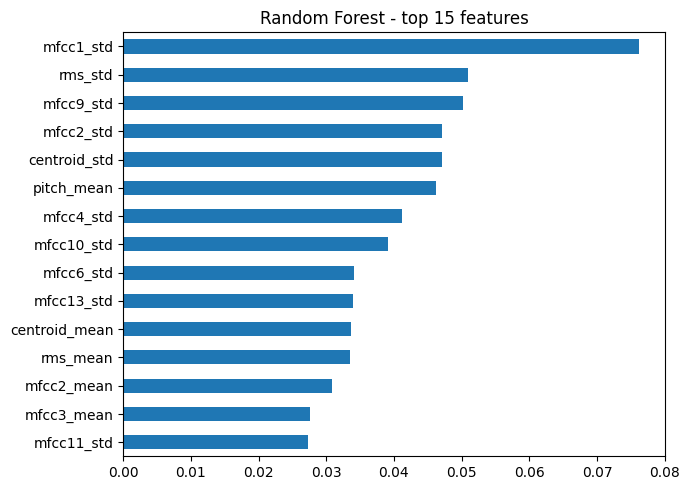

,group,n_features,cv_mean,val_acc
0,MFCC only,26,0.907,0.918
1,Pitch only,3,0.846,0.859
2,Energy/spectral only,5,0.856,0.835
3,All features,34,0.912,0.918


In [18]:
# 1) Top features
rf = models['Random Forest']
imp = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print("Top 10 features:\n", imp.head(10).round(3))

imp.head(15)[::-1].plot(kind='barh', figsize=(7, 5), title='Random Forest - top 15 features')
plt.tight_layout(); plt.show()

# 2) Group ablation (CV on train + val score)
groups = {
    'MFCC only':          [c for c in X_train.columns if c.startswith('mfcc')],
    'Pitch only':         ['pitch_mean', 'pitch_std', 'voiced_ratio'],
    'Energy/spectral only': ['rms_mean', 'rms_std', 'zcr_mean', 'centroid_mean', 'centroid_std'],
    'All features':       list(X_train.columns),
}

rows = []
for gname, cols in groups.items():
    idx = [list(X_train.columns).index(c) for c in cols]
    m = RandomForestClassifier(n_estimators=300, random_state=42)
    cvs = cross_val_score(m, X_train_s[:, idx], y_train, cv=cv, scoring='accuracy')
    m.fit(X_train_s[:, idx], y_train)
    rows.append({'group': gname, 'n_features': len(cols),
                 'cv_mean': round(cvs.mean(), 3),
                 'val_acc': round(m.score(X_val_s[:, idx], y_val), 3)})
display(pd.DataFrame(rows))

**Shortcut check: is the model just detecting recording loudness?** `rms_std` ranked #2, and loudness could reflect the recording setup. We remove every RMS feature and retrain. **Result:** CV 0.914 and validation 0.918, essentially unchanged, so the model is not leaning on loudness.

In [19]:
no_rms = [c for c in X_train.columns if not c.startswith('rms')]
idx = [list(X_train.columns).index(c) for c in no_rms]
m = RandomForestClassifier(n_estimators=300, random_state=42)
print("CV without RMS:", cross_val_score(m, X_train_s[:, idx], y_train, cv=cv).mean().round(3))
m.fit(X_train_s[:, idx], y_train)
print("Val without RMS:", round(m.score(X_val_s[:, idx], y_val), 3))

CV without RMS: 0.914
Val without RMS: 0.918


---
# Step 8: Model evaluation

**The rule:** the test set is opened **once**, for the model we already chose. Nothing is changed afterwards.

| Metric | Question it answers |
|---|---|
| **Accuracy** | Of all files, how many were right? |
| **Precision** | When it says Parkinson's, how often is it right? |
| **Recall** | Of the real patients, how many did it catch? |
| **F1** | One number balancing precision and recall |
| **ROC-AUC** | How well does it separate the classes at *every* threshold? (0.5 = coin flip, 1.0 = perfect) |

The model outputs a probability, and 0.5 is only one possible cut-off. The ROC curve plots the catch rate against the false-alarm rate for every cut-off.

Test accuracy: 0.942
Test ROC-AUC : 0.991

              precision    recall  f1-score   support

     Healthy       0.91      0.98      0.95        44
  Parkinsons       0.97      0.90      0.94        42

    accuracy                           0.94        86
   macro avg       0.94      0.94      0.94        86
weighted avg       0.94      0.94      0.94        86



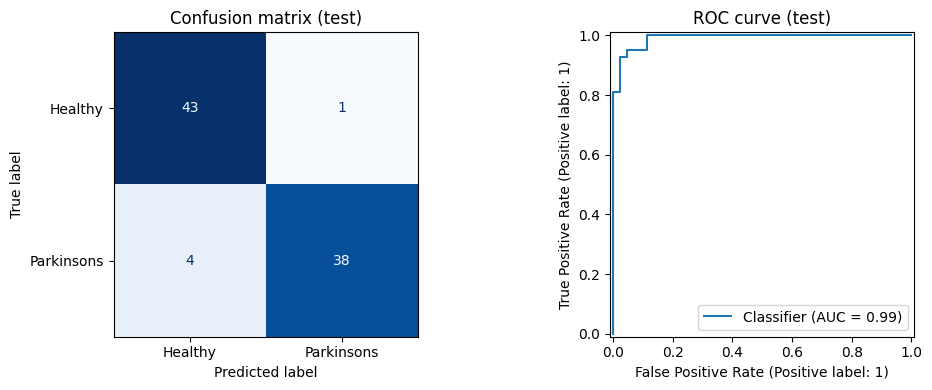

Misclassified test files:


,path,label,pred,prob_pd,duration_after
332,/content/data/Voice_Dataset/Parkinsons/parkins...,1,0,0.39,4.007625
88,/content/data/Voice_Dataset/Healthy/healthy_08...,0,1,0.56,4.300250
290,/content/data/Voice_Dataset/Parkinsons/parkins...,1,0,0.44,5.487875
340,/content/data/Voice_Dataset/Parkinsons/parkins...,1,0,0.49,3.568750
403,/content/data/Voice_Dataset/Parkinsons/parkins...,1,0,0.39,2.722875


In [20]:
final_model = models['Random Forest']
pred_test  = final_model.predict(X_test_s)
proba_test = final_model.predict_proba(X_test_s)[:, 1]

print("Test accuracy:", round(accuracy_score(y_test, pred_test), 3))
print("Test ROC-AUC :", round(roc_auc_score(y_test, proba_test), 3))
print()
print(classification_report(y_test, pred_test, target_names=['Healthy', 'Parkinsons']))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ConfusionMatrixDisplay(confusion_matrix(y_test, pred_test),
                       display_labels=['Healthy', 'Parkinsons']).plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion matrix (test)')
RocCurveDisplay.from_predictions(y_test, proba_test, ax=axes[1])
axes[1].set_title('ROC curve (test)')
plt.tight_layout(); plt.show()

# which test files did the model get wrong?
wrong = test_df.assign(pred=pred_test, prob_pd=proba_test.round(2))
wrong = wrong[wrong['label'] != wrong['pred']]
print("Misclassified test files:")
display(wrong[['path', 'label', 'pred', 'prob_pd', 'duration_after']])

**Reading the results**

| | Predicted healthy | Predicted Parkinson's |
|---|---|---|
| **Actually healthy (44)** | 43 | 1 (false alarm) |
| **Actually Parkinson's (42)** | 4 (missed) | 38 |

- Accuracy **0.942** (81 of 86), ROC-AUC **0.991**, Parkinson's recall **0.90**, precision **0.97**.
- All 5 mistakes have a Parkinson's probability between 0.39 and 0.56, close to the 0.5 line, so the model was *unsure*, not confidently wrong. Four were missed patients, which is the more serious kind of error.
- With 86 test files, one file is worth 1.2%, so report **"about 91 to 94%"**, not "94.2%". CV 0.91, validation 0.92 and test 0.94 all agree.

**Comparing all three models on the test set (for the report only).** The model was chosen earlier from CV and validation, and this comparison simply agrees with that choice. We do **not** pick a model from test scores.

,model,train_acc,val_acc,test_acc,test_recall_PD,test_f1_PD
0,Logistic Regression,0.808,0.824,0.802,0.857,0.809
1,SVM (RBF),0.957,0.918,0.884,0.833,0.875
2,Random Forest,1.000,0.918,0.942,0.905,0.938


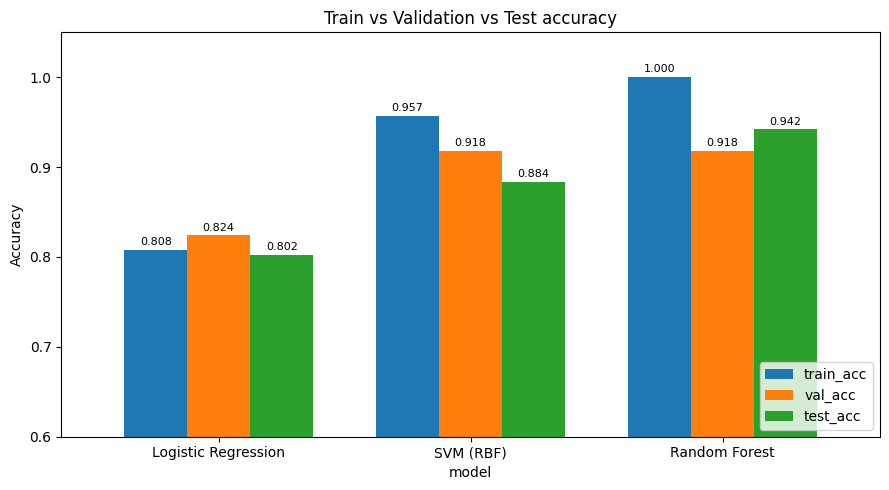

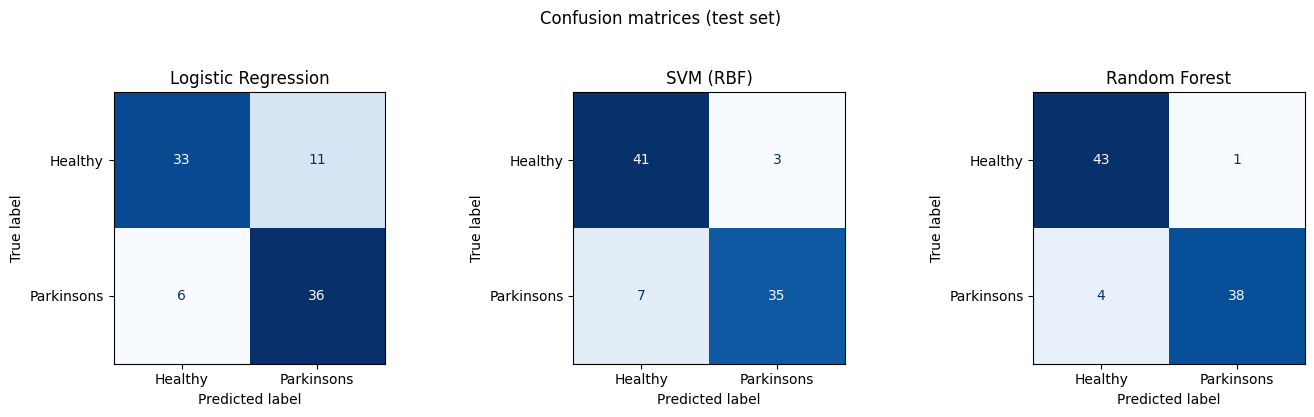

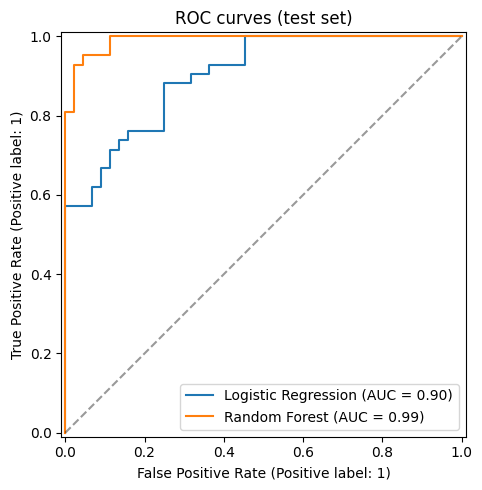

In [21]:
rows = []
for name, model in models.items():
    tr = accuracy_score(y_train, model.predict(X_train_s))
    va = accuracy_score(y_val,   model.predict(X_val_s))
    te_pred = model.predict(X_test_s)
    te = accuracy_score(y_test, te_pred)
    auc = roc_auc_score(y_test, model.predict_proba(X_test_s)[:, 1]) if hasattr(model, 'predict_proba') else np.nan
    rows.append({
        'model': name,
        'train_acc': round(tr, 3),
        'val_acc': round(va, 3),
        'test_acc': round(te, 3),
        'test_recall_PD': round(recall_score(y_test, te_pred), 3),
        'test_f1_PD': round(f1_score(y_test, te_pred), 3),
    })

summary = pd.DataFrame(rows)
display(summary)

# 1) grouped bar chart: train / val / test for each model
ax = summary.set_index('model')[['train_acc', 'val_acc', 'test_acc']].plot(
    kind='bar', figsize=(9, 5), rot=0, width=0.75)
ax.set_ylim(0.6, 1.05)
ax.set_ylabel('Accuracy')
ax.set_title('Train vs Validation vs Test accuracy')
for c in ax.containers:
    ax.bar_label(c, fmt='%.3f', fontsize=8, padding=2)
plt.legend(loc='lower right')
plt.tight_layout(); plt.show()

# 2) confusion matrix for each model (test set)
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (name, model) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, model.predict(X_test_s))
    ConfusionMatrixDisplay(cm, display_labels=['Healthy', 'Parkinsons']).plot(
        ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(name)
plt.suptitle('Confusion matrices (test set)', y=1.03)
plt.tight_layout(); plt.show()

# 3) ROC curves together
fig, ax = plt.subplots(figsize=(6, 5))
for name, model in models.items():
    if hasattr(model, 'predict_proba'):
        RocCurveDisplay.from_estimator(model, X_test_s, y_test, ax=ax, name=name)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Chance')
ax.set_title('ROC curves (test set)')
plt.tight_layout(); plt.show()

---
# Step 8b: Extra honesty checks (optional, run these)

Two checks about the limits of the 94%. Neither changes the model.

### Near-duplicates

Exact-fingerprint removal only catches byte-identical files. The same recording re-encoded or trimmed, or the same person saying the same thing twice, would survive. This cell measures how close each test file is to its nearest train file in feature space.

**How to read it:** if the smallest distances are far below the median (say 10 times smaller), there are near-twins between test and train and the score is somewhat inflated. If they are in the same range, there is no sign of near-copies. It **cannot prove** speaker overlap either way, so the limitation stays in the report.

In [22]:
nn = NearestNeighbors(n_neighbors=2).fit(X_train_s)
d_tt = nn.kneighbors(X_train_s)[0][:, 1]                 # each train file to its nearest OTHER train file
d_te = nn.kneighbors(X_test_s, n_neighbors=1)[0][:, 0]   # each test file to its nearest train file

print('median distance, train -> train:', np.median(d_tt).round(2))
print('median distance, test  -> train:', np.median(d_te).round(2))
print('10 smallest test -> train distances:', np.sort(d_te)[:10].round(2))

median distance, train -> train: 1.06
median distance, test  -> train: 1.6
10 smallest test -> train distances: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


### Do the two folders differ in their recording "signature"?

The dataset has no documentation, so we can't say how the recordings were made. This cell measures three things the recording chain leaves behind: the **noise floor** (how loud the quietest parts are), the share of energy above 2 kHz, and the 95% spectral rolloff.

**Caution:** a difference between the classes does not prove different recording conditions, because Parkinson's voices can genuinely be breathier. Similar numbers are reassuring; big differences are only *consistent with* either explanation.

In [23]:
def recording_signature(y, sr=SR):
    rms = librosa.feature.rms(y=y, frame_length=512, hop_length=128)[0]
    noise_floor_db = 20 * np.log10(np.percentile(rms, 10) + 1e-9)      # quietest 10% of frames
    S = np.abs(librosa.stft(y, n_fft=512, hop_length=128)) ** 2
    freqs = librosa.fft_frequencies(sr=sr, n_fft=512)
    hi_share = S[freqs > 2000].sum() / S.sum()                          # share of energy above 2 kHz
    rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr, roll_percent=0.95,
                                               n_fft=512, hop_length=128)[0].mean()
    return pd.Series({'noise_floor_db': noise_floor_db,
                      'energy_above_2k': hi_share,
                      'rolloff95_hz': rolloff})

sig = clean['audio'].apply(recording_signature)
sig['label'] = clean['label']
display(sig.groupby('label').agg(['mean', 'std']).round(3))

noise_floor_db        energy_above_2k        rolloff95_hz         
                mean    std            mean    std         mean      std
label                                                                   
0            -17.718  4.140           0.008  0.011     2524.119  414.380
1            -22.259  9.491           0.014  0.031     2712.363  425.488

---
# Step 9: Deployment

**Goal:** make the model usable by someone without this notebook.

**Save three things together:** the trained model, the **scaler** (new audio must be scaled with the *train* numbers) and the **column order** (features must reach the model in the same order as in training).

In [24]:
save_dir = '/content/drive/MyDrive/ml_project'
joblib.dump({'model': final_model,
             'scaler': scaler,
             'columns': list(X_train.columns)},
            f'{save_dir}/parkinsons_model.joblib')
print("Saved.")

Saved.


**The web app (Gradio).** `predict_voice` repeats exactly the training pipeline: preprocess, extract 34 features, scale, predict a probability. `gr.Interface` wraps it in a web page with an upload/record box, and `launch(share=True)` creates a **temporary public link** that works only while this Colab session is running.

> The saved output of this cell is cleared on purpose, so the temporary public link isn't stored in the file. Run it to get a fresh link.

In [ ]:
!pip install -q gradio
import gradio as gr

bundle = joblib.load(f'{save_dir}/parkinsons_model.joblib')
app_model, app_scaler, app_cols = bundle['model'], bundle['scaler'], bundle['columns']

def predict_voice(audio_path):
    if audio_path is None:
        return "Please upload or record a voice clip."
    y = preprocess(audio_path)                 # same load / trim / normalize as training
    if len(y) < SR * 1:
        return "Clip is too short (need at least ~1 second of voice)."
    feats = pd.DataFrame([extract_features(y)])[app_cols]
    x = app_scaler.transform(feats)
    p = app_model.predict_proba(x)[0, 1]
    return {"Parkinson's pattern": float(p), "Healthy pattern": float(1 - p)}

demo = gr.Interface(
    fn=predict_voice,
    inputs=gr.Audio(type="filepath", sources=["upload", "microphone"],
                    label="Voice recording"),
    outputs=gr.Label(num_top_classes=2, label="Model output"),
    title="Parkinson's Voice Screening (Demo)",
    description="Educational ML demo. Not a medical diagnosis. "
                "Trained on a small public dataset recorded under specific conditions.",
)
demo.launch(share=True)    # prints a public link

**Sanity check:** for one test file, the notebook and the app function must give the same probability. If they match (here 0.977 vs 0.9767), the app behaves exactly like the notebook.

In [26]:
sample = test_df.iloc[0]
print("File:", os.path.basename(sample['path']), "| true label:", sample['label'])
print("Notebook probability:", round(proba_test[0], 3))
print("App function says   :", predict_voice(sample['path']))

File: parkinsons_016.wav | true label: 1
Notebook probability: 0.977
App function says   : {"Parkinson's pattern": 0.9766666666666667, 'Healthy pattern': 0.023333333333333317}


---
# Limitations

- **Undocumented dataset:** no stated source, participants or recording protocol, and the labels are unverified. The 94% shows the model separates the two *folders*; it can't be claimed to detect Parkinson's in general.
- **No speaker IDs:** the same person may appear in both train and test, which can inflate the scores.
- **Small data:** 567 recordings and an 86-file test set (one file is worth 1.2%).
- **Domain shift:** recorded on a laptop microphone, a speech clip with pauses gave **70%** and **93%** "Parkinson's" for the *same healthy person*. The model reacts to variability, so pauses look like instability, and a different microphone and room were never seen in training. A confident output on new audio means nothing.
- **Internal pauses are not trimmed**, and variability features are sensitive to them.
- Feature importance shows association, not causation.
- **Educational demo only, not a medical diagnosis.**

# Future work

- Use a **documented dataset** with known participants, a standard recording protocol and speaker IDs, and split **by speaker**.
- Test on an **external** dataset from a different source.
- Remove internal silence (voice activity detection) and reduce noise before extracting features.
- Real data augmentation (light noise, small time-stretch) on the **training set only**.
- Calibrate the probabilities and add an input-quality check that refuses clips unlike the training data.

# Appendix: run only the app in a fresh session

If Colab was reset and you only want the demo, you don't need to rerun everything. Run these in a new session (this block is text on purpose, so *Run all* doesn't launch a second app):

```python
!pip install -q gradio librosa soundfile
from google.colab import drive
drive.mount('/content/drive')
```

then copy the `preprocess`, `extract_features` and `predict_voice` functions from Steps 4, 6 and 9, load the saved bundle with
`joblib.load('/content/drive/MyDrive/ml_project/parkinsons_model.joblib')`, and call `demo.launch(share=True)`.
The two feature functions must be **identical** to training (same `n_mfcc`, `n_fft`, `hop_length`), otherwise predictions are silently wrong.